# 🍎 Meyve Sınıflandırması – Transfer Öğrenmesi (VGG16)

> Önceden eğitilmiş VGG16 modeli ile meyve görüntülerini sınıflandırır.



## ⚙️ Adım 1: Ortam Kurulumu

In [1]:
# GPU / CPU durumunu kontrol et
import tensorflow as tf
print('TensorFlow versiyonu:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU bulundu: {gpus[0].name}')
else:
    print('⚠️  GPU bulunamadı, CPU kullanılacak (daha yavaş olacak)')


TensorFlow versiyonu: 2.20.0
✅ GPU bulundu: /physical_device:GPU:0


## 📦 Adım 2: Gerekli Kütüphaneler

In [2]:
# Colab'da TensorFlow, NumPy, Matplotlib zaten kurulu gelir.
# Yalnızca ek ihtiyaç duyulanları kuruyoruz:
!pip install -q scikit-learn

import warnings
import os
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print('✅ Kütüphaneler hazır.')


✅ Kütüphaneler hazır.


## 📥 Adım 3: Kütüphaneleri İçe Aktar

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.mixed_precision import set_global_policy
from collections import Counter
from tensorflow.keras.preprocessing.image import img_to_array, load_img

print('✅ Tüm kütüphaneler başarıyla içe aktarıldı.')


✅ Tüm kütüphaneler başarıyla içe aktarıldı.


## 📂 Adım 4: Veri Setini İndir ve Çıkart
> ⏳ İndirme ~30 dakika sürebilir. Sabit bir internet bağlantısı gereklidir.

In [4]:
import subprocess
import zipfile

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4yIRGlIpNfKEGJYMhZV52g/fruits-360-original-size.zip'
local_zip = 'fruits-360-original-size.zip'
extract_dir = 'fruits-360-original-size'

def download_dataset(url, output_file):
    print('Veri seti indiriliyor...')
    subprocess.run(['wget', '-q', '--show-progress', '-O', output_file, url], check=True)
    print('✅ İndirme tamamlandı.')

def extract_zip_in_chunks(zip_file, extract_to, batch_size=2000):
    print('Zip dosyası çıkartılıyor...')
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        files = zip_ref.namelist()
        total_files = len(files)
        for i in range(0, total_files, batch_size):
            batch = files[i:i + batch_size]
            for file in batch:
                zip_ref.extract(file, extract_to)
            print(f"  {min(i + batch_size, total_files)}/{total_files} dosya çıkartıldı...")
    print(f"✅ Veri seti '{extract_to}' klasörüne çıkartıldı.")

# İndir (yoksa)
if not os.path.exists(local_zip):
    download_dataset(url, local_zip)
else:
    print('Zip zaten mevcut, indirme atlanıyor.')

# Çıkart (yoksa)
if not os.path.exists(extract_dir):
    extract_zip_in_chunks(local_zip, extract_dir)
else:
    print('Veri seti zaten çıkartılmış, atlanıyor.')

# Zip temizle
if os.path.exists(local_zip):
    os.remove(local_zip)
    print(f'🗑️  Zip dosyası silindi: {local_zip}')


Veri seti indiriliyor...
✅ İndirme tamamlandı.
Zip dosyası çıkartılıyor...
  2000/12481 dosya çıkartıldı...
  4000/12481 dosya çıkartıldı...
  6000/12481 dosya çıkartıldı...
  8000/12481 dosya çıkartıldı...
  10000/12481 dosya çıkartıldı...
  12000/12481 dosya çıkartıldı...
  12481/12481 dosya çıkartıldı...
✅ Veri seti 'fruits-360-original-size' klasörüne çıkartıldı.
🗑️  Zip dosyası silindi: fruits-360-original-size.zip


## 🗂️ Adım 5: Veri Yollarını Ayarla

In [5]:
train_dir = 'fruits-360-original-size/fruits-360-original-size/Training'
val_dir   = 'fruits-360-original-size/fruits-360-original-size/Validation'
test_dir  = 'fruits-360-original-size/fruits-360-original-size/Test'

# Klasörlerin varlığını doğrula
for name, path in [('Train', train_dir), ('Val', val_dir), ('Test', test_dir)]:
    exists = os.path.isdir(path)
    status = '✅' if exists else '❌ BULUNAMADI'
    print(f'{status}  {name}: {path}')


✅  Train: fruits-360-original-size/fruits-360-original-size/Training
✅  Val: fruits-360-original-size/fruits-360-original-size/Validation
✅  Test: fruits-360-original-size/fruits-360-original-size/Test


## 🔄 Adım 6: Veri Üreticilerini Kur
Eğitim için veri artırma (data augmentation), doğrulama/test için yalnızca ölçekleme uygulanır.

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen  = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(64, 64), batch_size=32, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(64, 64), batch_size=32, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(64, 64), batch_size=32, class_mode='categorical'
)

print(f'\n📊 Eğitim örnekleri  : {train_generator.samples}')
print(f'📊 Doğrulama örnekleri: {val_generator.samples}')
print(f'📊 Test örnekleri     : {test_generator.samples}')
print(f'📊 Sınıf sayısı       : {train_generator.num_classes}')


Found 6231 images belonging to 24 classes.
Found 3114 images belonging to 24 classes.
Found 3110 images belonging to 24 classes.

📊 Eğitim örnekleri  : 6231
📊 Doğrulama örnekleri: 3114
📊 Test örnekleri     : 3110
📊 Sınıf sayısı       : 24


## 🏗️ Adım 7: VGG16 Tabanlı Model Mimarisini Oluştur
VGG16'nın konvolüsyon katmanları dondurulur, üstüne özel sınıflandırma katmanları eklenir.

In [7]:
# VGG16 temel modelini yükle (ImageNet ağırlıklarıyla, üst katman olmadan)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Tüm katmanları dondur (transfer learning – özellik çıkarıcı olarak kullan)
for layer in base_model.layers:
    layer.trainable = False

# Modeli oluştur
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation='softmax')
])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,853,208 (56.66 MB)

 Trainable params: 138,008 (539.09 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## ⚙️ Adım 8: Modeli Derle

In [8]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
print('✅ Model derlendi.')


✅ Model derlendi.


## 🏋️ Adım 9: Modeli Eğit
İlk aşamada yalnızca üst katmanlar eğitilir. `EarlyStopping` ile aşırı uyum önlenir.

In [9]:
# Callback'ler
lr_scheduler  = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# GPU varsa mixed precision etkinleştir (opsiyonel – hız artışı sağlar)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    set_global_policy('mixed_float16')
    print('⚡ Mixed precision (float16) etkinleştirildi.')
else:
    set_global_policy('float32')
    print('ℹ️  float32 politikası kullanılıyor.')

steps_per_epoch  = min(50, train_generator.samples // train_generator.batch_size)
validation_steps = min(25, val_generator.samples   // val_generator.batch_size)

print(f'steps_per_epoch={steps_per_epoch}, validation_steps={validation_steps}')

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[lr_scheduler, early_stopping]
)


⚡ Mixed precision (float16) etkinleştirildi.
steps_per_epoch=50, validation_steps=25
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.3038 - loss: 2.4093 - val_accuracy: 0.1388 - val_loss: 2.6458 - learning_rate: 0.0010
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.6103 - loss: 1.2964 - val_accuracy: 0.3438 - val_loss: 2.0217 - learning_rate: 0.0010
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.7100 - loss: 0.9404 - val_accuracy: 0.5700 - val_loss: 1.6687 - learning_rate: 0.0010
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7688 - loss: 0.7487 - val_accuracy: 0.6413 - val_loss: 1.3006 - learning_rate: 0.0010
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.7850 - loss: 0.6955 - val_accuracy: 0.7812 - val_loss: 0.9404 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


## 🔧 Adım 10: İnce Ayar (Fine-Tuning)
VGG16'nın son 5 katmanı dondurmadan çıkarılarak meyveye özgü özellikler öğrenilir.

In [10]:
num_layers = len(base_model.layers)
print(f'Temel modelde {num_layers} katman var.')

# Son 5 katmanı eğitilebilir yap
for layer in base_model.layers[-5:]:
    layer.trainable = True

# BatchNorm katmanlarını dondur (fine-tuning'de kararlılık için)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Daha düşük öğrenme oranıyla yeniden derle
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[lr_scheduler, early_stopping]
)


Temel modelde 19 katman var.
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 228ms/step - accuracy: 0.8297 - loss: 0.5601 - val_accuracy: 0.8112 - val_loss: 0.6215 - learning_rate: 1.0000e-05
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.8650 - loss: 0.4549 - val_accuracy: 0.7962 - val_loss: 0.5740 - learning_rate: 1.0000e-05
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.8625 - loss: 0.4439 - val_accuracy: 0.8763 - val_loss: 0.4103 - learning_rate: 1.0000e-05
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8951 - loss: 0.3854 - val_accuracy: 0.8512 - val_loss: 0.4266 - learning_rate: 1.0000e-05
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.9057 - loss: 0.3274 - val_accuracy: 0.9275 - val_loss: 0.2740 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 5.


## 📈 Adım 11: Test Setinde Değerlendir

In [11]:
test_loss, test_accuracy = model.evaluate(test_generator, steps=50, verbose=1)
print(f'\n🎯 Test Doğruluğu : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'📉 Test Kaybı      : {test_loss:.4f}')


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9450 - loss: 0.2478

🎯 Test Doğruluğu : 0.9450 (94.50%)
📉 Test Kaybı      : 0.2478


## 📊 Adım 12: Eğitim Grafiklerini Görselleştir

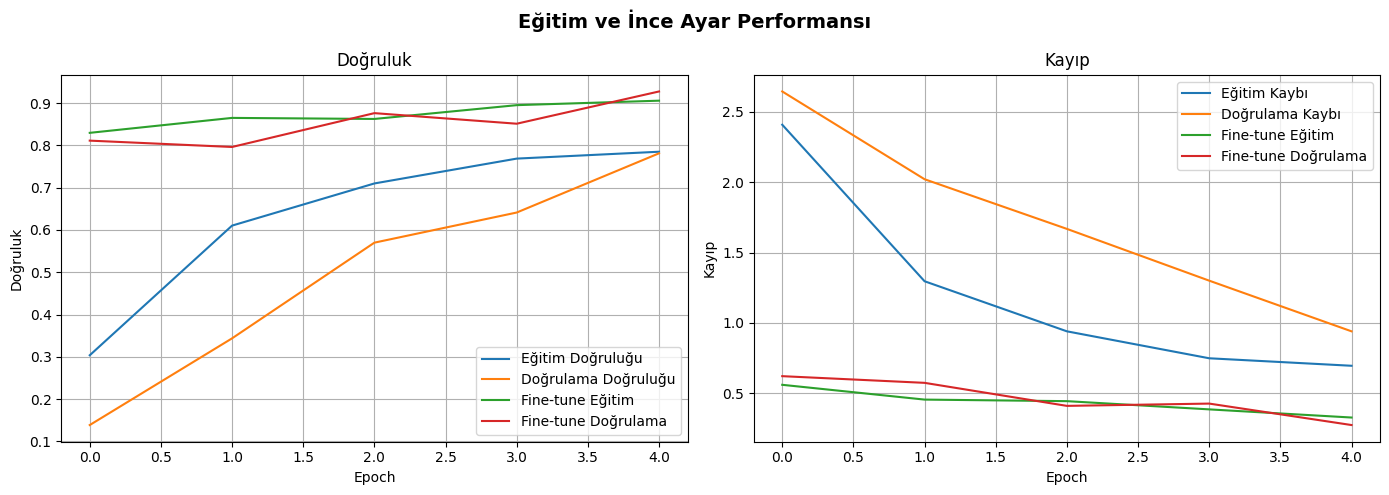

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Doğruluk grafiği
axes[0].plot(history.history['accuracy'],      label='Eğitim Doğruluğu')
axes[0].plot(history.history['val_accuracy'],  label='Doğrulama Doğruluğu')
axes[0].plot(history_fine.history['accuracy'],     label='Fine-tune Eğitim')
axes[0].plot(history_fine.history['val_accuracy'], label='Fine-tune Doğrulama')
axes[0].set_title('Doğruluk')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Doğruluk')
axes[0].legend()
axes[0].grid(True)

# Kayıp grafiği
axes[1].plot(history.history['loss'],      label='Eğitim Kaybı')
axes[1].plot(history.history['val_loss'],  label='Doğrulama Kaybı')
axes[1].plot(history_fine.history['loss'],     label='Fine-tune Eğitim')
axes[1].plot(history_fine.history['val_loss'], label='Fine-tune Doğrulama')
axes[1].set_title('Kayıp')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Kayıp')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Eğitim ve İnce Ayar Performansı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔍 Adım 13: Örnek Görüntüler Üzerinde Tahmin Yap

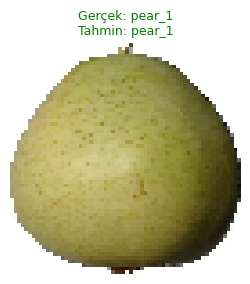

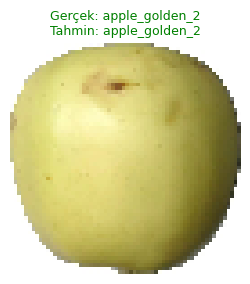

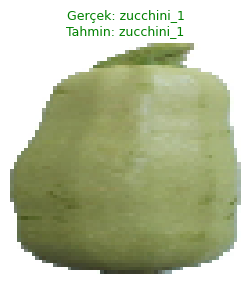

In [13]:
actual_count    = Counter()
predicted_count = Counter()
class_index_mapping = train_generator.class_indices

def get_class_name_from_index(predicted_index, mapping):
    for class_name, idx in mapping.items():
        if idx == predicted_index:
            return class_name
    return 'Bilinmiyor'

def visualize_prediction(img_path, mapping):
    class_name = os.path.basename(os.path.dirname(img_path))
    img = load_img(img_path, target_size=(64, 64))
    img_array = np.expand_dims(img_to_array(img) / 255.0, axis=0)
    prediction = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction, axis=-1)[0]
    predicted_class = get_class_name_from_index(predicted_index, mapping)
    actual_count[class_name] += 1
    predicted_count[predicted_class] += 1
    color = 'green' if class_name == predicted_class else 'red'
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f'Gerçek: {class_name}\nTahmin: {predicted_class}', color=color, fontsize=9)
    plt.axis('off')
    plt.show()

# Test klasöründen rastgele örnek görüntüler seç
sample_images = []
for class_folder in os.listdir(test_dir)[:3]:  # İlk 3 sınıftan birer görüntü
    class_path = os.path.join(test_dir, class_folder)
    if os.path.isdir(class_path):
        imgs = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
        if imgs:
            sample_images.append(os.path.join(class_path, imgs[0]))

if not sample_images:
    # Sabit yolları dene (orijinal dosyada kullanılan yollar)
    sample_images = [
        'fruits-360-original-size/fruits-360-original-size/Test/apple_braeburn_1/r0_11.jpg',
        'fruits-360-original-size/fruits-360-original-size/Test/pear_1/r0_103.jpg',
        'fruits-360-original-size/fruits-360-original-size/Test/cucumber_3/r0_103.jpg',
    ]

for img_path in sample_images:
    if os.path.exists(img_path):
        visualize_prediction(img_path, class_index_mapping)
    else:
        print(f'⚠️  Dosya bulunamadı: {img_path}')


## ✅ Sonuç

Bu çalışmada **transfer öğrenme** yöntemiyle VGG16 tabanlı bir meyve sınıflandırıcı oluşturduk:

- **Görev 1–2:** Kütüphaneler içe aktarıldı, veri seti indirildi ve yollar ayarlandı.
- **Görev 3–4:** Veri üreticileri (augmentation dahil) kuruldu.
- **Görev 5–6:** VGG16 tabanlı model oluşturuldu ve derlendi.
- **Görev 7–8:** İlk eğitim ve ince ayar (fine-tuning) tamamlandı.
- **Görev 9–11:** Model test setinde değerlendirildi ve sonuçlar görselleştirildi.

> Transfer öğrenme, sınırlı veriyle yüksek doğruluk elde etmenin güçlü bir yoludur.

---
*Orijinal: IBM Skills Network · Colab için düzenlendi*